# Phase 2 — Exploratory Data Analysis (EDA)
**Project:** FIFA World Cup 2026 — Portugal Win Probability  
**Goal:** Understand the data before building any models. Find patterns, validate assumptions, generate key stats.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
CHARTS = Path('../outputs/charts')
CHARTS.mkdir(parents=True, exist_ok=True)

## 1. Load Data

In [2]:
intl = pd.read_csv('../data/raw/international_results.csv')
intl['date'] = pd.to_datetime(intl['date'], format='mixed')

wc_raw = pd.read_csv('../data/raw/wc_matches.csv')
wc_raw.columns = wc_raw.columns.str.strip()

elo = pd.read_csv('../data/raw/elo_ratings.csv')
elo['date'] = pd.to_datetime(elo['date'], format='mixed')
elo['team'] = elo['team'].str.replace('\xa0', ' ', regex=False)

groups = pd.read_csv('../data/raw/wc_2026_groups.csv')

print(f'International results : {len(intl):,} rows ({intl["date"].min().year}-{intl["date"].max().year})')
print(f'WC matches            : {len(wc_raw):,} rows')
print(f'ELO ratings           : {len(elo):,} rows')
print(f'2026 Groups           : {len(groups)} rows')

International results : 49,287 rows (1872-2026)
WC matches            : 4,572 rows
ELO ratings           : 6,678 rows
2026 Groups           : 48 rows


## 2. Build Portugal Match Table
Portugal can appear as home_team or away_team. We normalise this into one unified table.

In [3]:
port_home = intl[intl['home_team'] == 'Portugal'].copy()
port_home['result']         = port_home.apply(lambda r: 'Win' if r.home_score > r.away_score else ('Draw' if r.home_score == r.away_score else 'Loss'), axis=1)
port_home['goals_scored']   = port_home['home_score']
port_home['goals_conceded'] = port_home['away_score']
port_home['venue']          = 'Home'

port_away = intl[intl['away_team'] == 'Portugal'].copy()
port_away['result']         = port_away.apply(lambda r: 'Win' if r.away_score > r.home_score else ('Draw' if r.away_score == r.home_score else 'Loss'), axis=1)
port_away['goals_scored']   = port_away['away_score']
port_away['goals_conceded'] = port_away['home_score']
port_away['venue']          = 'Away'

port = pd.concat([port_home, port_away]).sort_values('date').reset_index(drop=True)
print(f'Portugal total matches: {len(port)}')
port.tail(5)

Portugal total matches: 696


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,goals_scored,goals_conceded,venue
691,2026-03-28,Mexico,Portugal,0.0,0.0,Friendly,Mexico City,Mexico,False,Draw,0.0,0.0,Away
692,2026-03-31,United States,Portugal,0.0,2.0,Friendly,Atlanta,United States,False,Win,2.0,0.0,Away
693,2026-06-17,Portugal,DR Congo,NaN,NaN,FIFA World Cup,Houston,United States,True,Loss,NaN,NaN,Home
694,2026-06-23,Portugal,Uzbekistan,NaN,NaN,FIFA World Cup,Houston,United States,True,Loss,NaN,NaN,Home
695,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,Loss,NaN,NaN,Away


## 3. Chart 1 — Portugal Overall Win/Draw/Loss Record

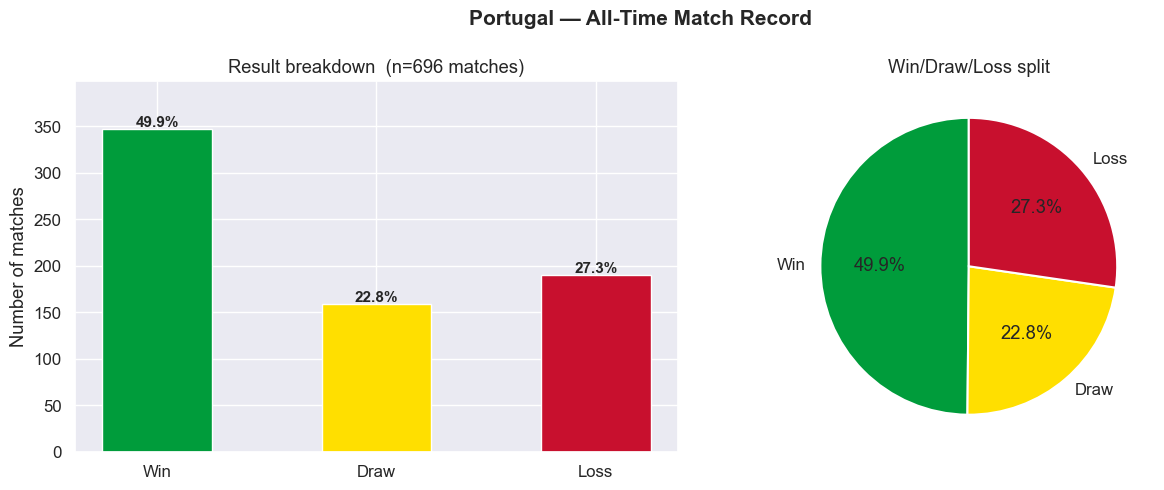

In [4]:
result_counts = port['result'].value_counts().reindex(['Win', 'Draw', 'Loss'])
total = len(port)
wdl_pct = result_counts / total * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Portugal — All-Time Match Record', fontsize=15, fontweight='bold')

colors = ['#009C3B', '#FFDF00', '#C8102E']
bars = axes[0].bar(result_counts.index, result_counts.values, color=colors, edgecolor='white', width=0.5)
for bar, pct in zip(bars, wdl_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title(f'Result breakdown  (n={total:,} matches)')
axes[0].set_ylabel('Number of matches')
axes[0].set_ylim(0, result_counts.max() * 1.15)

axes[1].pie(result_counts, labels=result_counts.index, colors=colors, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Win/Draw/Loss split')

plt.tight_layout()
plt.savefig(CHARTS / '01_portugal_wdl.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Chart 2 — Portugal Goals Over Time (5-Year Rolling Average)

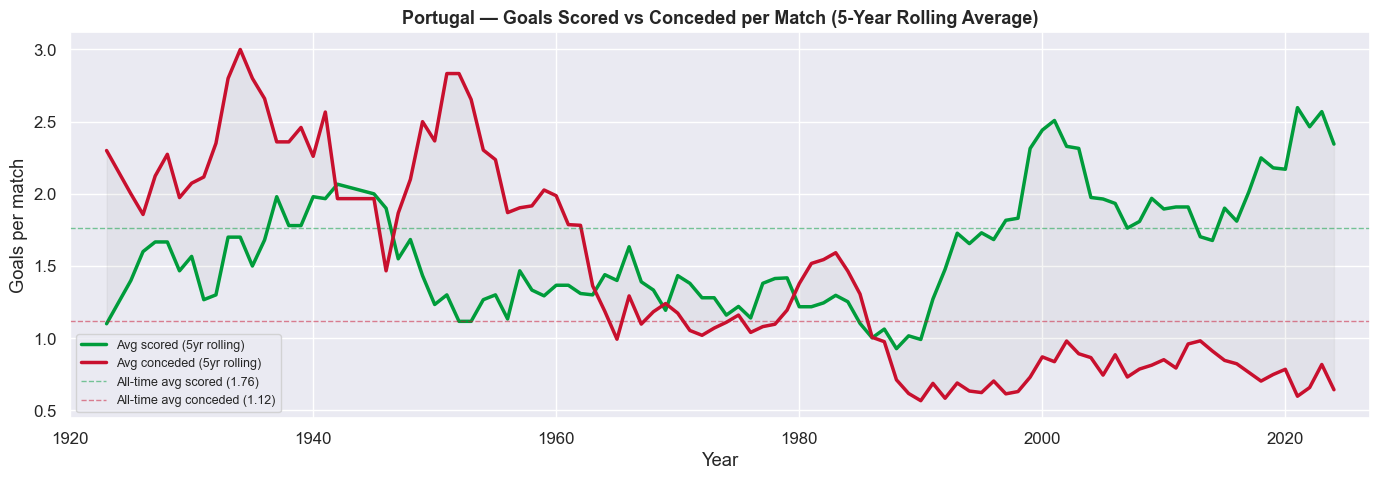

In [5]:
port_yr = port.copy()
port_yr['year'] = port_yr['date'].dt.year
yearly = port_yr.groupby('year')[['goals_scored', 'goals_conceded']].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(yearly.index, yearly['goals_scored'].rolling(5, center=True).mean(), color='#009C3B', lw=2.5, label=f"Avg scored (5yr rolling)")
ax.plot(yearly.index, yearly['goals_conceded'].rolling(5, center=True).mean(), color='#C8102E', lw=2.5, label=f"Avg conceded (5yr rolling)")
ax.fill_between(yearly.index, yearly['goals_scored'].rolling(5, center=True).mean(), yearly['goals_conceded'].rolling(5, center=True).mean(), alpha=0.08, color='grey')
ax.axhline(port['goals_scored'].mean(), color='#009C3B', lw=1, ls='--', alpha=0.5, label=f"All-time avg scored ({port['goals_scored'].mean():.2f})")
ax.axhline(port['goals_conceded'].mean(), color='#C8102E', lw=1, ls='--', alpha=0.5, label=f"All-time avg conceded ({port['goals_conceded'].mean():.2f})")
ax.set_title('Portugal — Goals Scored vs Conceded per Match (5-Year Rolling Average)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Goals per match')
ax.legend(fontsize=9)
ax.set_xlim(1920, port_yr['year'].max() + 1)
plt.tight_layout()
plt.savefig(CHARTS / '02_portugal_goals_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Chart 3 — Portugal Performance by Tournament Type

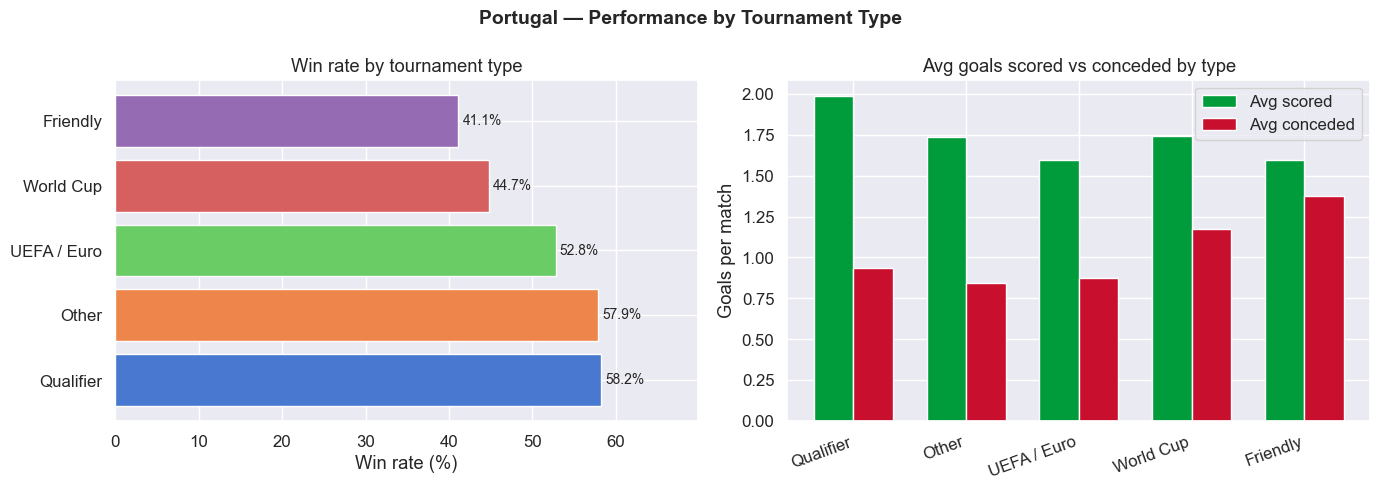

              matches  wins  win_rate  goals_scored  goals_conceded
tourney_type                                                       
Qualifier         280   163     58.21          1.99            0.94
Other              19    11     57.89          1.74            0.84
UEFA / Euro        72    38     52.78          1.60            0.88
World Cup          38    17     44.74          1.74            1.17
Friendly          287   118     41.11          1.60            1.37


In [6]:
def classify_tournament(t):
    t = str(t)
    if 'FIFA World Cup' in t and 'qualification' not in t.lower(): return 'World Cup'
    elif 'qualification' in t.lower() or 'Qualifier' in t: return 'Qualifier'
    elif 'Friendly' in t: return 'Friendly'
    elif 'UEFA' in t or 'European' in t: return 'UEFA / Euro'
    else: return 'Other'

port['tourney_type'] = port['tournament'].apply(classify_tournament)
by_type = port.groupby('tourney_type').agg(
    matches=('result', 'count'),
    wins=('result', lambda x: (x == 'Win').sum()),
    goals_scored=('goals_scored', 'mean'),
    goals_conceded=('goals_conceded', 'mean')
).assign(win_rate=lambda d: d['wins'] / d['matches'] * 100).sort_values('win_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Portugal — Performance by Tournament Type', fontsize=14, fontweight='bold')

palette = sns.color_palette('muted', len(by_type))
bars = axes[0].barh(by_type.index, by_type['win_rate'], color=palette, edgecolor='white')
for bar, val in zip(bars, by_type['win_rate']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)
axes[0].set_xlim(0, by_type['win_rate'].max() * 1.2)
axes[0].set_xlabel('Win rate (%)')
axes[0].set_title('Win rate by tournament type')

x = np.arange(len(by_type))
w = 0.35
axes[1].bar(x - w/2, by_type['goals_scored'], w, label='Avg scored', color='#009C3B', edgecolor='white')
axes[1].bar(x + w/2, by_type['goals_conceded'], w, label='Avg conceded', color='#C8102E', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(by_type.index, rotation=20, ha='right')
axes[1].set_ylabel('Goals per match')
axes[1].set_title('Avg goals scored vs conceded by type')
axes[1].legend()

plt.tight_layout()
plt.savefig(CHARTS / '03_portugal_by_tournament.png', dpi=150, bbox_inches='tight')
plt.show()
print(by_type[['matches', 'wins', 'win_rate', 'goals_scored', 'goals_conceded']].round(2).to_string())

## 6. Chart 4 — Goal Distribution vs Poisson (Validates Dixon-Coles Assumption)

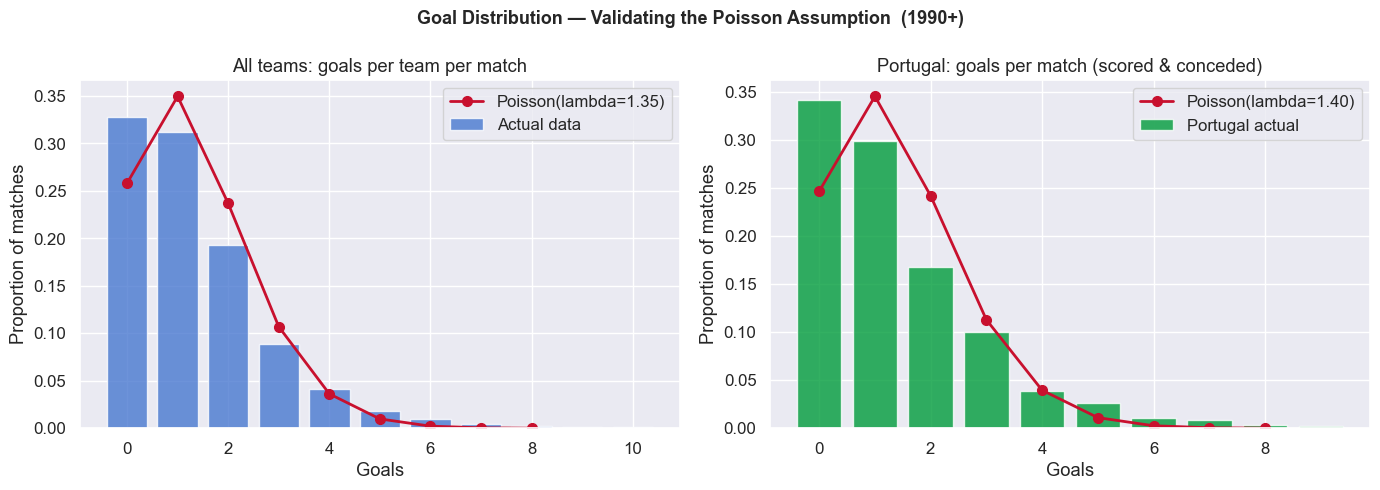

All-team mean goals/match : 1.355
Portugal mean goals/match : 1.400


In [7]:
recent = intl[intl['date'].dt.year >= 1990].copy()
all_goals = pd.concat([recent['home_score'], recent['away_score']]).dropna().astype(int)
goals_series = all_goals[all_goals <= 10]

mu = goals_series.mean()
poisson_pmf = stats.poisson.pmf(np.arange(0, 9), mu)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Goal Distribution — Validating the Poisson Assumption  (1990+)', fontsize=13, fontweight='bold')

counts = goals_series.value_counts(normalize=True).sort_index()
axes[0].bar(counts.index.tolist(), counts.values, color=sns.color_palette('muted')[0], edgecolor='white', label='Actual data', alpha=0.8)
axes[0].plot(np.arange(0, 9), poisson_pmf, 'o-', color='#C8102E', lw=2, ms=7, label=f'Poisson(lambda={mu:.2f})')
axes[0].set_title('All teams: goals per team per match')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Proportion of matches')
axes[0].legend()

port_goals_recent = pd.concat([port[port['date'].dt.year >= 1990]['goals_scored'], port[port['date'].dt.year >= 1990]['goals_conceded']]).dropna().astype(int)
port_goals_recent = port_goals_recent[port_goals_recent <= 10]
mu_port = port_goals_recent.mean()
poisson_port = stats.poisson.pmf(np.arange(0, 9), mu_port)
port_counts = port_goals_recent.value_counts(normalize=True).sort_index()
axes[1].bar(port_counts.index.tolist(), port_counts.values, color='#009C3B', edgecolor='white', label='Portugal actual', alpha=0.8)
axes[1].plot(np.arange(0, 9), poisson_port, 'o-', color='#C8102E', lw=2, ms=7, label=f'Poisson(lambda={mu_port:.2f})')
axes[1].set_title('Portugal: goals per match (scored & conceded)')
axes[1].set_xlabel('Goals')
axes[1].set_ylabel('Proportion of matches')
axes[1].legend()

plt.tight_layout()
plt.savefig(CHARTS / '04_goal_distribution_poisson.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'All-team mean goals/match : {mu:.3f}')
print(f'Portugal mean goals/match : {mu_port:.3f}')

## 7. Chart 5 — ELO Ratings: Portugal Over Time + Top 10 Teams

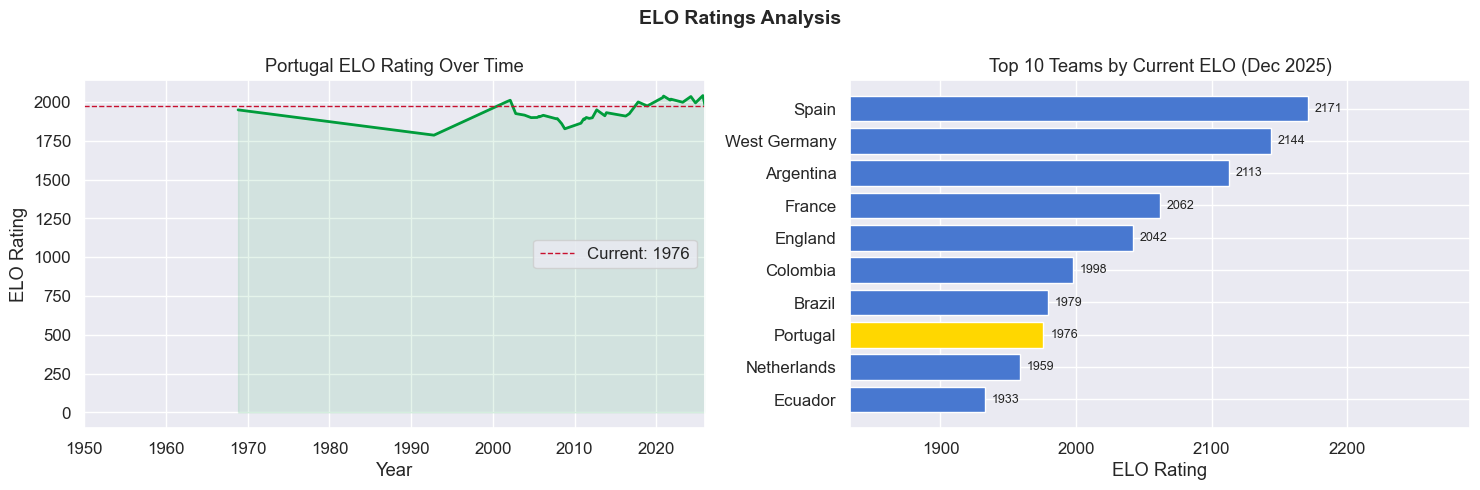

Portugal current ELO : 1976
Portugal ELO peak    : 2041  (2025)
Portugal ELO low     : 1786  (1992)


In [8]:
port_elo = elo[elo['team'] == 'Portugal'].sort_values('date').copy()
current_elo = port_elo.iloc[-1]['rating']
top10_now = elo.sort_values('date').groupby('team').last().sort_values('rating', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ELO Ratings Analysis', fontsize=14, fontweight='bold')

axes[0].plot(port_elo['date'], port_elo['rating'], color='#009C3B', lw=2)
axes[0].fill_between(port_elo['date'], port_elo['rating'], alpha=0.1, color='#009C3B')
axes[0].axhline(current_elo, color='#C8102E', lw=1, ls='--', label=f'Current: {current_elo:.0f}')
axes[0].set_title('Portugal ELO Rating Over Time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('ELO Rating')
axes[0].legend()
axes[0].set_xlim(pd.Timestamp('1950-01-01'), port_elo['date'].max())

colors_bar = ['gold' if t == 'Portugal' else sns.color_palette('muted')[0] for t in top10_now.index]
hbars = axes[1].barh(top10_now.index[::-1], top10_now['rating'][::-1], color=colors_bar[::-1], edgecolor='white')
for bar, val in zip(hbars, top10_now['rating'][::-1]):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=9)
axes[1].set_xlim(top10_now['rating'].min() - 100, top10_now['rating'].max() + 120)
axes[1].set_title('Top 10 Teams by Current ELO (Dec 2025)')
axes[1].set_xlabel('ELO Rating')

plt.tight_layout()
plt.savefig(CHARTS / '05_elo_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Portugal current ELO : {current_elo:.0f}')
print(f'Portugal ELO peak    : {port_elo["rating"].max():.0f}  ({port_elo.loc[port_elo["rating"].idxmax(), "date"].year})')
print(f'Portugal ELO low     : {port_elo["rating"].min():.0f}  ({port_elo.loc[port_elo["rating"].idxmin(), "date"].year})')

## 8. Chart 6 — World Cup Stage Analysis (Upset Rate)

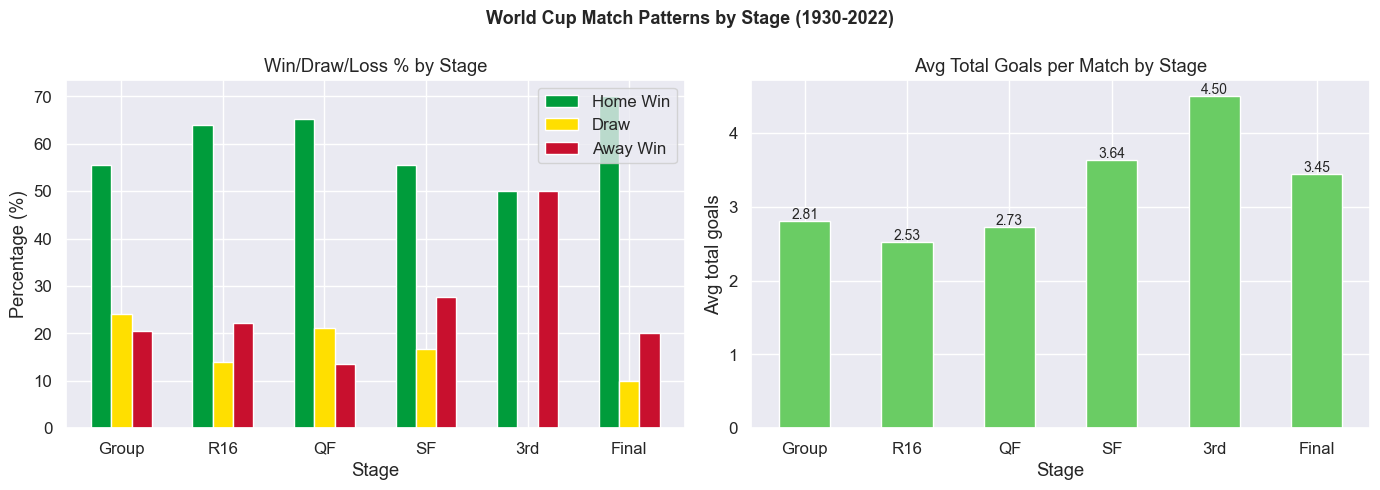

result       Home Win  Draw  Away Win
stage_clean                          
Group            55.5  24.1      20.4
R16              63.9  13.9      22.2
QF               65.2  21.2      13.6
SF               55.6  16.7      27.8
3rd              50.0   0.0      50.0
Final            70.0  10.0      20.0


In [9]:
wc = wc_raw.dropna(subset=['Home Team Goals', 'Away Team Goals']).copy()
wc['home_goals'] = wc['Home Team Goals'].astype(int)
wc['away_goals'] = wc['Away Team Goals'].astype(int)
wc['result'] = wc.apply(lambda r: 'Home Win' if r.home_goals > r.away_goals else ('Draw' if r.home_goals == r.away_goals else 'Away Win'), axis=1)

stage_map = {
    'Group 1':'Group','Group 2':'Group','Group 3':'Group','Group 4':'Group',
    'Group A':'Group','Group B':'Group','Group C':'Group','Group D':'Group',
    'Group E':'Group','Group F':'Group','Group G':'Group','Group H':'Group',
    'Round of 16':'R16','Quarter-finals':'QF','Semi-finals':'SF',
    'Third place':'3rd','Final':'Final',
    'First round':'Group','Second round':'R16','Third round':'QF',
}
wc['stage_clean'] = wc['Stage'].str.strip().map(stage_map).fillna('Group')
stage_order = ['Group','R16','QF','SF','3rd','Final']
wc_stage = wc.groupby('stage_clean')['result'].value_counts(normalize=True).unstack(fill_value=0) * 100
wc_stage = wc_stage.reindex([s for s in stage_order if s in wc_stage.index])
avg_goals_by_stage = wc.groupby('stage_clean')[['home_goals','away_goals']].mean()
avg_goals_by_stage['total'] = avg_goals_by_stage['home_goals'] + avg_goals_by_stage['away_goals']
avg_goals_by_stage = avg_goals_by_stage.reindex([s for s in stage_order if s in avg_goals_by_stage.index])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('World Cup Match Patterns by Stage (1930-2022)', fontsize=13, fontweight='bold')

cols_to_plot = [c for c in ['Home Win', 'Draw', 'Away Win'] if c in wc_stage.columns]
wc_stage[cols_to_plot].plot(kind='bar', ax=axes[0], color=['#009C3B','#FFDF00','#C8102E'], edgecolor='white', width=0.6)
axes[0].set_title('Win/Draw/Loss % by Stage')
axes[0].set_xlabel('Stage')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(loc='upper right')

axes[1].bar(avg_goals_by_stage.index, avg_goals_by_stage['total'], color=sns.color_palette('muted')[2], edgecolor='white', width=0.5)
axes[1].set_title('Avg Total Goals per Match by Stage')
axes[1].set_xlabel('Stage')
axes[1].set_ylabel('Avg total goals')
for i, (idx, row) in enumerate(avg_goals_by_stage.iterrows()):
    axes[1].text(i, row['total'] + 0.03, f"{row['total']:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(CHARTS / '06_wc_stage_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(wc_stage[cols_to_plot].round(1).to_string())

## 9. Chart 7 — Group K Comparison

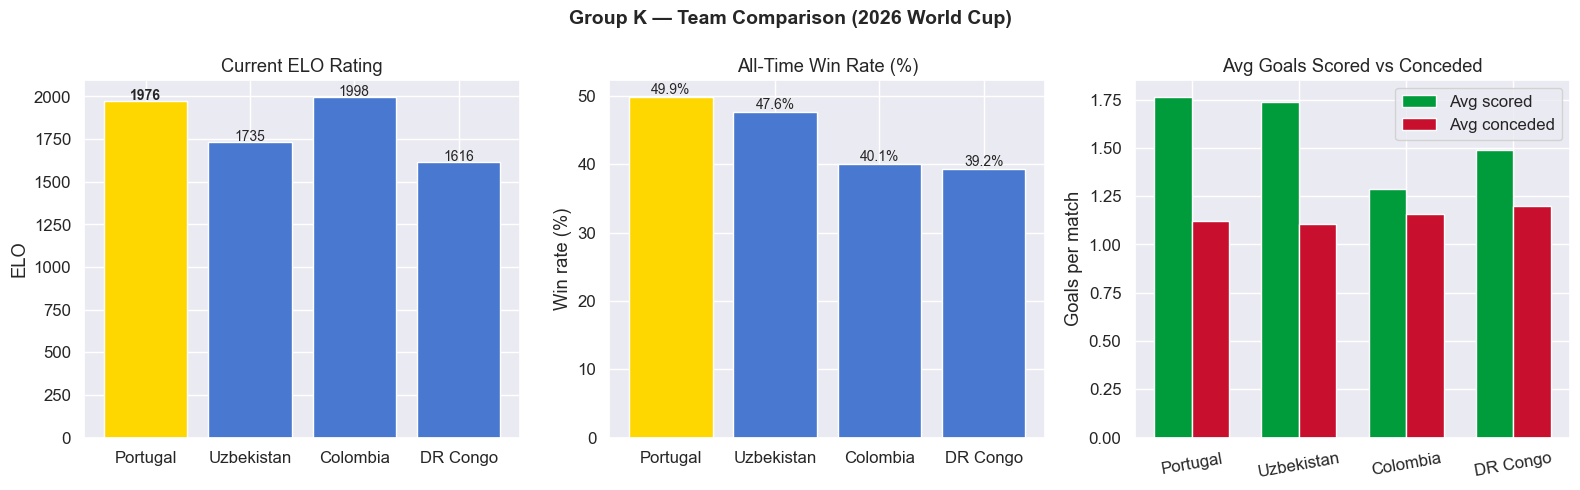

            matches  win_rate  avg_scored  avg_conceded     elo
team                                                           
Portugal        696     49.86        1.76          1.12  1976.0
Uzbekistan      355     47.61        1.74          1.11  1735.0
Colombia        639     40.06        1.29          1.16  1998.0
DR Congo        525     39.24        1.49          1.20  1616.0


In [10]:
group_k = groups[groups['group'] == 'K']['team'].tolist()
latest_elo = elo.sort_values('date').groupby('team').last().reset_index()

elo_name_map = {'DR Congo': 'Democratic Republic of Congo'}
def get_elo(team):
    lookup = elo_name_map.get(team, team)
    row = latest_elo[latest_elo['team'] == lookup]
    return row['rating'].values[0] if len(row) else np.nan

k_elo = {t: get_elo(t) for t in group_k}

k_stats = []
for team in group_k:
    tm_home = intl[intl['home_team'] == team]
    tm_away = intl[intl['away_team'] == team]
    total = len(tm_home) + len(tm_away)
    wins = (tm_home['home_score'] > tm_home['away_score']).sum() + (tm_away['away_score'] > tm_away['home_score']).sum()
    gs = pd.concat([tm_home['home_score'], tm_away['away_score']]).mean()
    gc = pd.concat([tm_home['away_score'], tm_away['home_score']]).mean()
    k_stats.append({'team': team, 'matches': total, 'win_rate': wins/total*100 if total else 0,
                    'avg_scored': gs, 'avg_conceded': gc, 'elo': k_elo.get(team, np.nan)})

k_df = pd.DataFrame(k_stats).set_index('team')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Group K — Team Comparison (2026 World Cup)', fontsize=14, fontweight='bold')
bar_colors = ['gold' if t == 'Portugal' else sns.color_palette('muted')[0] for t in k_df.index]

axes[0].bar(k_df.index, k_df['elo'], color=bar_colors, edgecolor='white')
axes[0].set_title('Current ELO Rating')
axes[0].set_ylabel('ELO')
for i, (t, row) in enumerate(k_df.iterrows()):
    if not np.isnan(row['elo']):
        axes[0].text(i, row['elo'] + 5, f"{row['elo']:.0f}", ha='center', fontsize=10, fontweight='bold' if t == 'Portugal' else 'normal')

axes[1].bar(k_df.index, k_df['win_rate'], color=bar_colors, edgecolor='white')
axes[1].set_title('All-Time Win Rate (%)')
axes[1].set_ylabel('Win rate (%)')
for i, (t, row) in enumerate(k_df.iterrows()):
    axes[1].text(i, row['win_rate'] + 0.5, f"{row['win_rate']:.1f}%", ha='center', fontsize=10)

x = np.arange(len(k_df))
w = 0.35
axes[2].bar(x - w/2, k_df['avg_scored'], w, color='#009C3B', edgecolor='white', label='Avg scored')
axes[2].bar(x + w/2, k_df['avg_conceded'], w, color='#C8102E', edgecolor='white', label='Avg conceded')
axes[2].set_xticks(x)
axes[2].set_xticklabels(k_df.index, rotation=10)
axes[2].set_title('Avg Goals Scored vs Conceded')
axes[2].set_ylabel('Goals per match')
axes[2].legend()

plt.tight_layout()
plt.savefig(CHARTS / '07_group_k_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(k_df[['matches', 'win_rate', 'avg_scored', 'avg_conceded', 'elo']].round(2).to_string())

## 10. Key Findings Summary

In [11]:
port_wc = port[port['tournament'] == 'FIFA World Cup']

print('=== KEY FINDINGS — PHASE 2 EDA ===')
print(f'\nPortugal overall ({len(port)} matches):')
print(f'  Win rate     : {(port["result"]=="Win").mean()*100:.1f}%')
print(f'  Avg scored   : {port["goals_scored"].mean():.3f} per match')
print(f'  Avg conceded : {port["goals_conceded"].mean():.3f} per match')
print(f'\nPortugal in World Cups ({len(port_wc)} matches):')
print(f'  Win rate     : {(port_wc["result"]=="Win").mean()*100:.1f}%')
print(f'  Avg scored   : {port_wc["goals_scored"].mean():.3f} per match')
print(f'  Avg conceded : {port_wc["goals_conceded"].mean():.3f} per match')
print(f'\nGroup K ELO ratings:')
for t, r in k_elo.items():
    print(f'  {t}: {r:.0f}' if not np.isnan(r) else f'  {t}: N/A')
print(f'\nPoisson fit: global lambda = {mu:.3f} goals/team/match')
print('  -> Poisson is a reasonable model for goal scoring')

=== KEY FINDINGS — PHASE 2 EDA ===

Portugal overall (696 matches):
  Win rate     : 49.9%
  Avg scored   : 1.765 per match
  Avg conceded : 1.120 per match

Portugal in World Cups (38 matches):
  Win rate     : 44.7%
  Avg scored   : 1.743 per match
  Avg conceded : 1.171 per match

Group K ELO ratings:
  Portugal: 1976
  Uzbekistan: 1735
  Colombia: 1998
  DR Congo: 1616

Poisson fit: global lambda = 1.355 goals/team/match
  -> Poisson is a reasonable model for goal scoring
